# Project Summary:

In this project, I implemented three Value at Risk (VaR) models — Historical Simulation, Variance-Covariance, and Monte Carlo Simulation, to estimate potential portfolio losses. I used 10 years of market data and conducted backtesting with a 250-day rolling window.

To validate the models, I applied violation ratio and Kupiec’s Proportion of Failures (POF) test. The results showed that at 99% confidence level, all methods failed, indicating that they underestimated extreme losses. However, at 90%, 95%, and 97% confidence levels, the models performed well.

To investigate further, I excluded the COVID crash (data until January 31, 2020, roughly 5 years). After this adjustment, all methods passed backtesting at all confidence levels, confirming that extreme market events significantly impact VaR accuracy.

#### Required packages

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import scipy.linalg
import matplotlib.pyplot as plt
from scipy.stats import chi2
import statsmodels.api as sm

np.random.seed(100)

#### Function to calculate VaR using Historical Simulation

In [2]:

def calculate_var_historical(portfolio,confidence_level):
    VaR_hist=[np.percentile(portfolio,100-cl) for cl in confidence_level]
    return VaR_hist
    

#### Function to calculate VaR using Variance-Covariance method

In [3]:

def calculate_var_varcov(portfolio,confidence_level):
    portfolio_mean=portfolio.mean()
    portfolio_std=portfolio.std()
    VaR_varcov=[stats.norm.ppf(1-cl/100)*portfolio_std+portfolio_mean for cl in confidence_level]
    return VaR_varcov
    

#### Function to calculate VaR using Monte Carlo Simulation

In [4]:

def calculate_var_monte_carlo(stock_return,weights,confidence_level,num_simulations=10**4):

    volatility = stock_return.std()
    drift=stock_return.mean()-0.5*(volatility**2)
    
    # Generate correlated random returns using Cholesky decomposition
    corr_matrix=stock_return.corr()
    cholesky_factor=scipy.linalg.cholesky(corr_matrix,lower=True)
    
    random_returns=np.random.normal(size=(len(weights),num_simulations))
    correlated_random_returns=np.dot(cholesky_factor,random_returns)
    
    simulated_returns=drift.values[:,None]+volatility.values[:,None]*correlated_random_returns
    simulated_portfolio_returns=np.dot(weights,simulated_returns)

    VaR_mc=[np.percentile(simulated_portfolio_returns, 100 - cl) for cl in confidence_level]
    
    return VaR_mc
    

We consider a portfolio with the same weightage as the SENSEX index (top 30 companies in the BSE). We calculate Value at Risk (VaR) at different confidence levels (90%, 95%, 97%, 99%) using a rolling window of 250 days (approximately 1 year). We collect data for the last 10 years and perform backtesting.

In [5]:
# The following data is downloaded from the BSE website. The data contains NIFTY50 stocks and weightage as on September 30, 2024. 
sensex_data=pd.read_csv("Sensex_data.csv")
sensex_data.head()

,Company Name,Stock Symbol (NSE),Weightage (%)
0,Adani Ports & Special Economic Zone Ltd,ADANIPORTS,1.09
1,Asian Paints Ltd.,ASIANPAINT,1.54
2,Axis Bank Ltd.,AXISBANK,3.61
3,Bajaj Finserv Ltd.,BAJAJFINSV,1.10
4,Bajaj Finance Ltd.,BAJFINANCE,2.21


In [6]:
sensex_stocks=sensex_data["Stock Symbol (NSE)"].to_numpy()
# ".NS" needs to be added as Yahoo Finance downloads the stock data in this way (".NS" represents NSE)
sensex_stocks=[symbol+".NS" for symbol in sensex_stocks]  
sensex_weightage=pd.to_numeric(sensex_data["Weightage (%)"]).to_numpy()
sensex_weightage=sensex_weightage/sensex_weightage.sum()  # So that the sum of weights is 1

# Last 10 year data
start_date="2015-01-01"  #Date format is "YYYY-MM-DD"
end_date="2024-12-31"



confidence_level=[90,95,97,99]

window_size=250

We use the adjusted close price of each stocks saved in SENSEX stocks return.csv file. Which can be downloaded from the folowing command too.

stock_data=yf.download(ticker_set, start=start_date, end=end_date,auto_adjust=False)['Adj Close']

In [7]:
stock_data=pd.read_csv("SENSEX stocks return.csv")
stock_data.set_index(stock_data["Date"],inplace=True)
stock_data.drop(columns=["Date"],inplace=True)
stock_return=np.log(stock_data/stock_data.shift(1)).dropna()  # We consider the log return

In [8]:
portfolio_return=np.dot(stock_return,sensex_weightage)

In [9]:
VaR_hist_portfolio=[]
VaR_varcov_portfolio=[]
VaR_mc_portfolio=[]

for i in range(window_size, len(stock_return)):
    VaR_hist_portfolio.append(calculate_var_historical(portfolio_return[i-window_size:i],confidence_level))
    VaR_varcov_portfolio.append(calculate_var_varcov(portfolio_return[i-window_size:i],confidence_level))
    VaR_mc_portfolio.append(calculate_var_monte_carlo(stock_return.iloc[i-window_size:i],sensex_weightage,confidence_level))
    

In [10]:
portfolio_metrics=pd.DataFrame(
    data={"Actual return":portfolio_return[window_size:],
         },
    index=stock_return.index[window_size:]
)


for i,cl in enumerate(confidence_level):
    portfolio_metrics["VaR_hist "+str(cl)+"%"]=[x[i] for x in VaR_hist_portfolio]
    portfolio_metrics["VaR_varcov "+str(cl)+"%"]=[x[i] for x in VaR_varcov_portfolio]
    portfolio_metrics["VaR_mc "+str(cl)+"%"]=[x[i] for x in VaR_mc_portfolio]



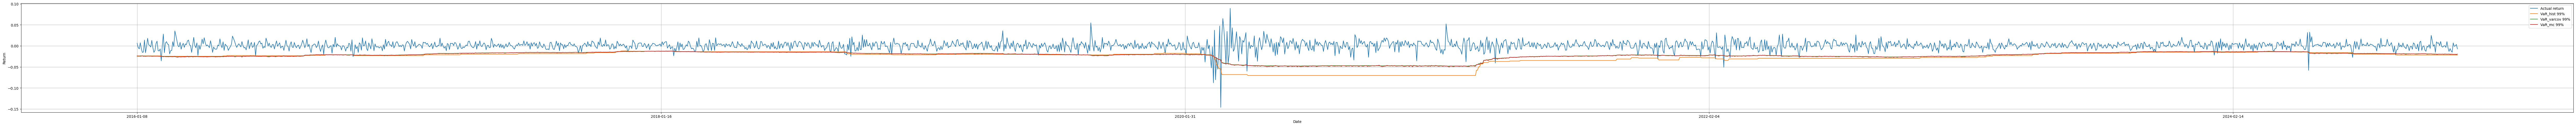

In [11]:
fig=portfolio_metrics[["Actual return","VaR_hist 99%", "VaR_varcov 99%", "VaR_mc 99%"]].plot(figsize=(100,5))
fig.set_xlabel("Date")
fig.set_ylabel("Return")
fig.grid(True)
plt.tight_layout() 
plt.show()

In [12]:
(total_observations,tot_col)=portfolio_metrics.shape
model_violation=[(portfolio_metrics.iloc[:, i] > portfolio_metrics.iloc[:, 0]).sum() for i in range(1,tot_col)]
expected_violation=[round(total_observations*(1-(cl/100))) for cl in confidence_level]
    

In [13]:
violation_data=np.array(model_violation).reshape(len(confidence_level), 3)
violation_summary=pd.DataFrame(violation_data, columns=["Historical", "Variance-Covariance", "Monte-Carlo"],index=[str(x)+"%" for x in confidence_level])
violation_summary["Expected violation"]=expected_violation
violation_summary

,Historical,Variance-Covariance,Monte-Carlo,Expected violation
90%,230,194,190,221
95%,123,106,103,111
97%,70,69,68,66
99%,34,40,38,22


#### Violation Ratio in VaR Backtesting


The *Violation Ratio (VR)* checks if the actual number of VaR breaches aligns with expectations:
<br> $VR = \frac{x}{n \cdot \alpha}$

where:  
- $x$=Actual VaR breaches  
- $n$=Total observations  
- $\alpha$=VaR confidence level (e.g., for 99% VaR,=0.01).

**Interpretation:**
- $VR \approx 1$: Well-calibrated model  
- $VR>1$: Underestimates risk (too optimistic)  
- $VR < 1$: Overestimates risk (too conservative)
- Commonly, violation ratio in the range of $[0.8,1.2]$ considered as good. 


In [14]:
divisors=[total_observations*(1-(cl/100)) for cl in confidence_level]
violation_ratio=violation_summary.iloc[:,:3].div(divisors,axis=0)
violation_ratio


,Historical,Variance-Covariance,Monte-Carlo
90%,1.038375,0.875847,0.857788
95%,1.110609,0.957111,0.930023
97%,1.053424,1.038375,1.023326
99%,1.534989,1.805869,1.715576


#### Conclusion from Violation Ratio:

- All methods for calculating VaR-90%, VaR-95%, and VaR-97% perform reasonably well.
- However, for VaR-99%, all methods fail to meet the expected criteria.

### The Kupiec Test:
<br> Also known as the Proportion of Failures (POF) Test, is a statistical test used in Value-at-Risk (VaR) backtesting to verify whether the observed violations (losses exceeding VaR) occur at the expected frequency. It is based on a likelihood ratio (LR) test. <br> The null hypothesis $H_0$ assumes that the proportion of VaR violations matches the expected probability $\alpha$: <br> where:
- $p = \frac{x}{n}$ is the observed proportion of violations,
- $x$ is the number of observed VaR breaches,
- $n$ is the total number of observations,
- $\alpha$ is the expected violation rate (e.g., for 99\% VaR,  $\alpha$ = 0.01).
<br> The *Kupiec likelihood ratio statistic* is given by:
<br> $LR_{POF} = -2 \log \left( \frac{ (1 - \alpha)^{n - x} \alpha^x }{ (1 - p)^{n - x} p^x } \right)$

<br> Under the null hypothesis, $LR_{POF}$ follows a chi-square distribution with one degree of freedom.

<br> Generally, if p-value $> 0.05$ (that is at 95\% confidence level), we fail to reject $H_0$, indicating that the VaR model is correctly calibrated.



In [15]:
def calculate_kupiec_test_stat(violation_summary,confidence_level,total_observations,row,col):
    expected_prob=1-(confidence_level[row]/100)
    violations=violation_summary.iloc[row,col]
    violation_prob=violations/total_observations
    
    LR=-2*np.log((((1-expected_prob)/(1-violation_prob)) ** (total_observations- violations)) *((expected_prob/violation_prob) ** violations))
    p_value=1-chi2.cdf(LR, df=1)
    return p_value
    

In [16]:
kupiec_test_p_value=pd.DataFrame(index=violation_ratio.index, columns=violation_ratio.columns)


for i in range(violation_ratio.shape[0]):  
    for j in range(violation_ratio.shape[1]):  
        kupiec_test_p_value.iloc[i, j] = calculate_kupiec_test_stat(violation_summary,confidence_level,total_observations,i, j)

In [17]:
kupiec_test_p_value

,Historical,Variance-Covariance,Monte-Carlo
90%,0.549404,0.047077,0.022539
95%,0.240262,0.641016,0.44477
97%,0.661065,0.752244,0.847474
99%,0.018976,0.000615,0.002128


#### Conclusion from Kupiec Test:

- The results align with the violation ratio analysis, showing consistent performance for VaR-90%, VaR-95%, and VaR-97%.
- However, at VaR-99%, all methods fall short of the expected standards.

### Next Step:

Since VaR-99% fails, it suggests that extreme events like the COVID crisis significantly impact the results. To examine performance in a more stable market environment, we will exclude the COVID period by using data up to January 31, 2020, and conduct backtesting.

In [18]:
portfolio_metrics_pre_covid=portfolio_metrics.loc[:"2020-01-31"]

In [19]:
(total_observations_pre_covid,tot_col)=portfolio_metrics_pre_covid.shape
model_violation_pre_covid=[(portfolio_metrics_pre_covid.iloc[:, i] > portfolio_metrics_pre_covid.iloc[:, 0]).sum() for i in range(1,tot_col)]
expected_violation_pre_covid=[round(total_observations_pre_covid*(1-(cl/100))) for cl in confidence_level]
    

In [20]:
violation_data_pre_covid=np.array(model_violation_pre_covid).reshape(len(confidence_level), 3)
violation_summary_pre_covid=pd.DataFrame(violation_data_pre_covid, columns=["Historical", "Var-Cov", "Monte-Carlo"],index=[str(x)+"%" for x in confidence_level])
violation_summary_pre_covid["Expected violation"]=expected_violation_pre_covid
violation_summary_pre_covid

,Historical,Var-Cov,Monte-Carlo,Expected violation
90%,101,92,89,100
95%,53,47,46,50
97%,28,30,30,30
99%,15,14,12,10


In [21]:
divisors=[total_observations_pre_covid*(1-(cl/100)) for cl in confidence_level]
violation_ratio_pre_covid=violation_summary_pre_covid.iloc[:,:3].div(divisors,axis=0)
violation_ratio_pre_covid


,Historical,Var-Cov,Monte-Carlo
90%,1.008991,0.919081,0.889111
95%,1.058941,0.939061,0.919081
97%,0.932401,0.999001,0.999001
99%,1.498501,1.398601,1.198801


#### Conclusion from Violation Ratio:

- All the methods for VaR-90%, VaR-95%, and VaR-97% successfully pass the test.
- For VaR-99%, the Historical and Variance-Covariance methods fail, while the Monte Carlo method meets the criteria.

In [22]:
kupiec_test_p_value_pre_covid=pd.DataFrame(index=violation_ratio_pre_covid.index, columns=violation_ratio_pre_covid.columns)

# Populate the DataFrame using nested loops
for i in range(violation_ratio_pre_covid.shape[0]):  # Row index
    for j in range(violation_ratio_pre_covid.shape[1]):  # Column index
        kupiec_test_p_value_pre_covid.iloc[i, j] = calculate_kupiec_test_stat(violation_summary_pre_covid,confidence_level,total_observations,i, j)

In [23]:
kupiec_test_p_value_pre_covid

,Historical,Var-Cov,Monte-Carlo
90%,0.0,0.0,0.0
95%,0.0,0.0,0.0
97%,0.0,0.0,0.0
99%,0.104884,0.06195,0.01759


#### Conclusion from Kupiec Test:

- All methods successfully pass the test across different VaR levels.

## Project Conclusions:

- VaR models like historical simulation, variance-covariance, and Monte Carlo simulation perform well under normal market conditions but struggle to capture extreme tail risks, as seen at 99% confidence level during the COVID crash.
- Removing extreme events improves model performance, highlighting the sensitivity of VaR to market shocks.
- VaR alone is insufficient for risk management—supplementary methods like Expected Shortfall (CVaR) or stress testing are necessary for better tail risk estimation.
- While more advanced models (GARCH, Extreme value theory, etc.) could improve accuracy, my focus was on industry-standard VaR methods for practical implementation.